# Installing Dependencies

In [1]:
# !pip install adapters
# !pip install datasets scikit-learn pandas
# !pip install adapters
# !pip install hf_xet
# !pip install accelerate>=0.26.0
# !pip install seaborn
# !pip install -U ipywidgets
# !pip install -U matplotlib

# Importing Libraries

In [2]:
import os
import math
import itertools
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

import adapters
from adapters import AutoAdapterModel, AdapterConfig, AdapterTrainer
from adapters.composition import Stack

from transformers import (
    AutoTokenizer,
    TrainingArguments,
    DataCollatorWithPadding,
    get_cosine_schedule_with_warmup,
)
from datasets import Dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42) 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 4060


# Configuration

In [4]:
BASE_MODEL = 'indolem/indobert-base-uncased'

# ── Paths ────────────────────────────────────────────────────────────────
SOURCE_TRAIN_CSV       = '../../datasets/telemedicine_preprocessed/train.csv'   # source train (labeled)
SOURCE_TEST_CSV        = '../../datasets/telemedicine_preprocessed/test.csv'    # source test  (labeled)
SOURCE_UNLABELED_CSV   = '../../datasets/telemedicine_preprocessed/train.csv'   # same as train, used for domain MMD
TARGET_UNLABELED_CSV   = '../../datasets/lazada_train_preprocessed.csv'      # target unlabeled (domain MMD)
TARGET_EVAL_CSV        = '../../datasets/lazada_test_preprocessed.csv'       # target labeled   (evaluation)

# ── Labels ───────────────────────────────────────────────────────────────
LABEL2ID = {'negative': 0, 'positive': 1}
ID2LABEL = {0: 'negative', 1: 'positive'}

# ── Tokenization ─────────────────────────────────────────────────────────
MAX_LENGTH = 128
SEED       = 42

# ── Domain Adapter ───────────────────────────────────────────────────────
DOMAIN_ADAPTER_NAME      = 'domain_adapter'
DOMAIN_ADAPTER_REDUCTION = 16
DOMAIN_EPOCHS            = 3
BATCH_SIZE               = 32
DOMAIN_LR                = 1e-5
WARMUP_RATIO             = 0.1
WEIGHT_DECAY             = 0.02
MAX_GRAD_NORM            = 1.0

# ── MMD ──────────────────────────────────────────────────────────────────
MMD_KERNEL_MUL = 2.0
MMD_KERNEL_NUM = 5

# ── Task Adapter ─────────────────────────────────────────────────────────
TASK_ADAPTER_NAME      = 'task_adapter'
TASK_ADAPTER_REDUCTION = 16
TASK_EPOCHS            = 3
TASK_LR                = 1e-3
LABEL_SMOOTHING        = 0.05

OUTPUT_DIR = './indobert_adapter_only'
DROPOUT    = 0.2

In [5]:
print('Configuration loaded.')
print(f'  Base model               : {BASE_MODEL}')
print(f'  Source train CSV         : {SOURCE_TRAIN_CSV}')
print(f'  Source test  CSV         : {SOURCE_TEST_CSV}')
print(f'  Target unlabeled CSV     : {TARGET_UNLABELED_CSV}')
print(f'  Target eval  CSV         : {TARGET_EVAL_CSV}')
print(f'  Batch size               : {BATCH_SIZE}')
print(f'  Domain LR / Task LR      : {DOMAIN_LR} / {TASK_LR}')
print(f'  Warmup ratio             : {WARMUP_RATIO}')
print(f'  Label smoothing          : {LABEL_SMOOTHING}')

Configuration loaded.
  Base model               : indolem/indobert-base-uncased
  Source train CSV         : ../../datasets/telemedicine_preprocessed/train.csv
  Source test  CSV         : ../../datasets/telemedicine_preprocessed/test.csv
  Target unlabeled CSV     : ../../datasets/lazada_train_preprocessed.csv
  Target eval  CSV         : ../../datasets/lazada_test_preprocessed.csv
  Batch size               : 32
  Domain LR / Task LR      : 1e-05 / 0.001
  Warmup ratio             : 0.1
  Label smoothing          : 0.05


# Load Data

In [6]:
# ── Label normalisation helpers ──────────────────────────────────────────
def _resolve_text_column(df):
    for col in ['content', 'reviewContent', 'text', 'review']:
        if col in df.columns: return col
    raise ValueError(f'No text column found. Got: {df.columns.tolist()}')

def _resolve_label_column(df):
    for col in ['label', 'sentiment', 'target']:
        if col in df.columns: return col
    raise ValueError(f'No label column found. Got: {df.columns.tolist()}')

def _normalize_labels(series):
    return series.astype(str).str.strip().str.lower().replace({
        'pos':     'positive', 'neg':     'negative',
        '1':       'positive', '0':       'negative',
        'positif': 'positive', 'negatif': 'negative',
        'true':    'positive', 'false':   'negative',
    })

def clean_dataframe(df, text_col, label_col=None):
    cols = [text_col] + ([label_col] if label_col else [])
    out  = df[cols].copy().dropna(subset=[text_col])
    out[text_col] = out[text_col].astype(str).str.strip()
    out  = out[out[text_col] != '']
    if label_col:
        out = out.dropna(subset=[label_col])
        out[label_col] = _normalize_labels(out[label_col])
        out = out[out[label_col].isin(LABEL2ID)]
    return out.reset_index(drop=True)

# ── Load source TRAIN (used for domain MMD + task adapter training) ──────────
source_train_df = pd.read_csv(SOURCE_TRAIN_CSV)
TEXT_COL_SOURCE = _resolve_text_column(source_train_df)
LABEL_COL       = _resolve_label_column(source_train_df)
source_train_df = clean_dataframe(source_train_df, TEXT_COL_SOURCE, LABEL_COL)
source_train_df['label_id'] = source_train_df[LABEL_COL].map(LABEL2ID)

# ── Load source TEST (used for source evaluation) ─────────────────────────
source_test_df = pd.read_csv(SOURCE_TEST_CSV)
source_test_df = clean_dataframe(source_test_df, TEXT_COL_SOURCE, LABEL_COL)
source_test_df['label_id'] = source_test_df[LABEL_COL].map(LABEL2ID)

# ── Keep backward-compat alias ───────────────────────────────────────────
source_df = source_train_df

print(f'Source TRAIN : {source_train_df.shape}  | {dict(source_train_df[LABEL_COL].value_counts())}')
print(f'Source TEST  : {source_test_df.shape}  | {dict(source_test_df[LABEL_COL].value_counts())}')

Source TRAIN : (6696, 3)  | {'negative': 3348, 'positive': 3348}
Source TEST  : (1674, 3)  | {'negative': 837, 'positive': 837}


In [7]:
# ── Load target UNLABELED (domain MMD alignment) ─────────────────────────
target_df = pd.read_csv(TARGET_UNLABELED_CSV)
TEXT_COL_TARGET = _resolve_text_column(target_df)
target_df   = clean_dataframe(target_df, TEXT_COL_TARGET)
target_texts = target_df[TEXT_COL_TARGET].tolist()

# ── Load target LABELED TEST (target evaluation) ──────────────────────────
target_test_df = pd.read_csv(TARGET_EVAL_CSV)
TEXT_COL_TARGET_TEST = _resolve_text_column(target_test_df)
LABEL_COL_TARGET     = _resolve_label_column(target_test_df)
target_test_df = clean_dataframe(target_test_df, TEXT_COL_TARGET_TEST, LABEL_COL_TARGET)
target_test_df['label_id'] = target_test_df[LABEL_COL_TARGET].map(LABEL2ID)

print(f'Target unlabeled  : {len(target_texts):,} samples')
print(f'Target labeled test: {target_test_df.shape} | {dict(target_test_df[LABEL_COL_TARGET].value_counts())}')
print(f'Sample source : {source_train_df[TEXT_COL_SOURCE].iloc[0]}')
print(f'Sample target : {target_texts[0]}')

Target unlabeled  : 8,142 samples
Target labeled test: (2042, 3) | {'positive': 1022, 'negative': 1020}
Sample source : tidak ada bonus gratis konsultasi yang ada pembayaran bukan nya membantu tapi membanting tidak ada rasa tolong nya semua pakai uang sama saja bohong sudah dapat gaji harap lagi uang dari rakyat tidak mampu lebih unistal dari pada di save tidak ada gunanya juga karena harus membayar minimal nya aplikasi dan dokter nya pelit dengan kesehatan bagi rakyat kecil yang tak mampu
Sample target : star saja


# Training Setup

## Load Tokenizer and Base Model

In [8]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
model     = AutoAdapterModel.from_pretrained(BASE_MODEL)

adapters.init(model)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded  : {model.__class__.__name__}')
print(f'Total params  : {total_params:,}')


Model loaded  : BertAdapterModel
Total params  : 111,182,259


## MMD Loss Function

In [9]:
def gaussian_kernel(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    n_samples = source.size(0) + target.size(0)
    total     = torch.cat([source, target], dim=0)

    total0 = total.unsqueeze(0).expand(n_samples, n_samples, -1)
    total1 = total.unsqueeze(1).expand(n_samples, n_samples, -1)
    L2_distance = ((total0 - total1) ** 2).sum(2)

    if fix_sigma:
        bandwidth = fix_sigma
    else:
        bandwidth = torch.sum(L2_distance.detach()) / (n_samples ** 2 - n_samples)

    bandwidth /= kernel_mul ** (kernel_num // 2)
    bandwidth_list = [bandwidth * (kernel_mul ** i) for i in range(kernel_num)]

    kernel_val = [torch.exp(-L2_distance / bw) for bw in bandwidth_list]
    return sum(kernel_val)

In [10]:
def mmd_loss(source, target, kernel_mul=2.0, kernel_num=5, fix_sigma=None):
    batch_size = source.size(0)
    kernels    = gaussian_kernel(source, target, kernel_mul, kernel_num, fix_sigma)

    XX = kernels[:batch_size, :batch_size].mean()
    YY = kernels[batch_size:, batch_size:].mean()
    XY = kernels[:batch_size, batch_size:].mean()

    return XX + YY - 2 * XY

In [11]:
print('MMD loss defined.')
print(f'  Kernel multiplier : {MMD_KERNEL_MUL}')
print(f'  Number of kernels : {MMD_KERNEL_NUM}')

MMD loss defined.
  Kernel multiplier : 2.0
  Number of kernels : 5


##  Prepare DataLoaders for Domain Adapter

In [12]:
def tokenize_texts(texts, max_length=MAX_LENGTH):
    ds = Dataset.from_dict({'text': texts})
    ds = ds.map(
        lambda ex: tokenizer(
            ex['text'],
            truncation=True,
            max_length=max_length,
            padding=False
        ),
        batched=True,
        remove_columns=['text'],
        desc='Tokenizing'
    )
    ds.set_format(type='torch', columns=['input_ids', 'attention_mask'])
    return ds

In [13]:
source_texts_domain = source_df[TEXT_COL_SOURCE].tolist()

source_domain_ds = tokenize_texts(source_texts_domain)
target_domain_ds = tokenize_texts(target_texts)

Tokenizing:   0%|          | 0/6696 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/8142 [00:00<?, ? examples/s]

In [14]:
collator = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors='pt')

# seed generators so shuffling is reproducible
g_src = torch.Generator(); g_src.manual_seed(SEED)
g_tgt = torch.Generator(); g_tgt.manual_seed(SEED + 1)

source_domain_loader = DataLoader(
    source_domain_ds, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collator, generator=g_src
)
target_domain_loader = DataLoader(
    target_domain_ds, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collator, generator=g_tgt
)

In [15]:
print(f'Source domain batches : {len(source_domain_loader)}')
print(f'Target domain batches : {len(target_domain_loader)}')

Source domain batches : 210
Target domain batches : 255


# Add Domain Adapter to Model

In [16]:
domain_adapter_config = AdapterConfig.load(
    'pfeiffer',
    reduction_factor=DOMAIN_ADAPTER_REDUCTION
)

model.add_adapter(DOMAIN_ADAPTER_NAME, config=domain_adapter_config)
model.train_adapter(DOMAIN_ADAPTER_NAME)
model.to(device)

There are adapters available but none are activated for the forward pass.


BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
             

In [17]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Domain adapter added : {DOMAIN_ADAPTER_NAME}')
print(f'Trainable params     : {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

Domain adapter added : domain_adapter
Trainable params     : 1,486,656 / 112,076,787 (1.33%)


In [18]:
# Verifikasi semua parameter sudah di device yang sama
devices = set(p.device for p in model.parameters())
print(f'Model devices        : {devices}')  # harus cuma 1 device

Model devices        : {device(type='cuda', index=0)}


# Model Training

## 1. Train Domain Adapter (MMD)

In [19]:
optimizer_domain = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=DOMAIN_LR,
    weight_decay=WEIGHT_DECAY,
)

In [20]:
model.train()

BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
             

In [21]:
# Cek dulu struktur output model
with torch.no_grad():
    sample = next(iter(source_domain_loader))
    sample = {k: v.to(device) for k, v in sample.items()}
    test_out = model(
        input_ids=sample['input_ids'],
        attention_mask=sample['attention_mask'],
        output_hidden_states=True
    )
    print(f'Output type   : {type(test_out)}')
    print(f'Output keys   : {test_out.keys() if hasattr(test_out, "keys") else dir(test_out)}')
    if hasattr(test_out, 'hidden_states') and test_out.hidden_states is not None:
        print(f'Hidden states : {len(test_out.hidden_states)} layers, shape: {test_out.hidden_states[-1].shape}')

Output type   : <class 'transformers.modeling_outputs.MaskedLMOutput'>
Output keys   : odict_keys(['logits', 'hidden_states'])
Hidden states : 13 layers, shape: torch.Size([32, 53, 768])


In [22]:
domain_losses = []
global_step   = 0

In [23]:
# Cosine scheduler with warmup
steps_per_epoch_domain = max(len(source_domain_loader), len(target_domain_loader))
total_domain_steps     = DOMAIN_EPOCHS * steps_per_epoch_domain
warmup_domain_steps    = int(WARMUP_RATIO * total_domain_steps)

scheduler_domain = get_cosine_schedule_with_warmup(
    optimizer_domain,
    num_warmup_steps=warmup_domain_steps,
    num_training_steps=total_domain_steps,
)

print(f'Domain training: {DOMAIN_EPOCHS} epochs x {steps_per_epoch_domain} steps = {total_domain_steps} total')
print(f'Warmup steps: {warmup_domain_steps}')

Domain training: 3 epochs x 255 steps = 765 total
Warmup steps: 76


In [24]:
epoch_pbar = tqdm(range(DOMAIN_EPOCHS), desc='Epochs', position=0)

Epochs:   0%|          | 0/3 [00:00<?, ?it/s]

In [25]:
for epoch in epoch_pbar:
    epoch_loss = 0.0

    # Use max() + cycle() so ALL data from both domains is seen every epoch
    # (matches friend's train_domain_adapter approach)
    steps_this_epoch = max(len(source_domain_loader), len(target_domain_loader))
    src_iter = itertools.cycle(source_domain_loader)
    tgt_iter = itertools.cycle(target_domain_loader)

    step_pbar = tqdm(
        range(steps_this_epoch),
        desc=f'  Epoch {epoch+1}/{DOMAIN_EPOCHS}',
        position=1,
        leave=False
    )

    for step in step_pbar:
        src_batch = {k: v.to(device) for k, v in next(src_iter).items()}
        tgt_batch = {k: v.to(device) for k, v in next(tgt_iter).items()}

        src_outputs = model(
            input_ids=src_batch['input_ids'],
            attention_mask=src_batch['attention_mask'],
            output_hidden_states=True
        )
        tgt_outputs = model(
            input_ids=tgt_batch['input_ids'],
            attention_mask=tgt_batch['attention_mask'],
            output_hidden_states=True
        )

        # Mean pooling (matches friend's _mean_pool; richer than CLS alone) ──
        def mean_pool(hidden_states, attention_mask):
            last_h = hidden_states[-1]                        # (B, L, H)
            mask   = attention_mask.unsqueeze(-1).float()     # (B, L, 1)
            return (last_h * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

        src_feat = mean_pool(src_outputs.hidden_states, src_batch['attention_mask'])
        tgt_feat = mean_pool(tgt_outputs.hidden_states, tgt_batch['attention_mask'])

        loss = mmd_loss(src_feat, tgt_feat, MMD_KERNEL_MUL, MMD_KERNEL_NUM)

        optimizer_domain.zero_grad()
        loss.backward()
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, model.parameters()),
            MAX_GRAD_NORM
        )
        optimizer_domain.step()
        scheduler_domain.step()

        epoch_loss += loss.item()
        global_step += 1
        avg_loss     = epoch_loss / (step + 1)

        step_pbar.set_postfix({
            'MMD Loss': f'{avg_loss:.6f}',
            'step'    : f'{step+1}/{steps_this_epoch}'
        })

    step_pbar.close()

    avg_epoch_loss = epoch_loss / steps_this_epoch
    domain_losses.append(avg_epoch_loss)

    epoch_pbar.set_postfix({
        'avg MMD Loss': f'{avg_epoch_loss:.6f}',
        'epoch'       : f'{epoch+1}/{DOMAIN_EPOCHS}'
    })

    tqdm.write(f'Epoch {epoch+1}/{DOMAIN_EPOCHS} done — avg MMD loss: {avg_epoch_loss:.6f}')
    tqdm.write('-' * 60)

  Epoch 1/3:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 1/3 done — avg MMD loss: 0.217233
------------------------------------------------------------


  Epoch 2/3:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 2/3 done — avg MMD loss: 0.208070
------------------------------------------------------------


  Epoch 3/3:   0%|          | 0/255 [00:00<?, ?it/s]

Epoch 3/3 done — avg MMD loss: 0.206851
------------------------------------------------------------


In [26]:
print(f'MMD loss per epoch: {[f"{l:.6f}" for l in domain_losses]}')

MMD loss per epoch: ['0.217233', '0.208070', '0.206851']


In [27]:
domain_adapter_dir = os.path.join(OUTPUT_DIR, 'domain_adapter')
os.makedirs(domain_adapter_dir, exist_ok=True)

model.save_adapter(domain_adapter_dir, DOMAIN_ADAPTER_NAME)

print(f'Domain adapter saved to: {domain_adapter_dir}')
for f in os.listdir(domain_adapter_dir):
    fpath   = os.path.join(domain_adapter_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {f:30s} ({size_kb:.1f} KB)')

Domain adapter saved to: ./indobert_adapter_only\domain_adapter
  adapter_config.json            (1.1 KB)
  pytorch_adapter.bin            (3512.0 KB)


In [28]:
# Use the proper train/test CSVs — no random split needed
train_df = source_train_df
test_df  = source_test_df

# ── Class weights from TRAIN distribution ────────────────────────────────
counts   = train_df['label_id'].value_counts().sort_index()
total    = len(train_df)
class_weights = torch.tensor(
    [total / (2 * counts[i]) for i in range(2)],
    dtype=torch.float
).to(device)
print(f'Train  : {len(train_df):,} samples')
print(f'Test   : {len(test_df):,} samples  (source test set)')
print(f'Class weights: neg={class_weights[0]:.3f}  pos={class_weights[1]:.3f}')

Train  : 6,696 samples
Test   : 1,674 samples  (source test set)
Class weights: neg=1.000  pos=1.000


In [29]:
print(f'Train dataset: {len(train_df):,} | Source test: {len(test_df):,} | Target test: {len(target_test_df):,}')

Train dataset: 6,696 | Source test: 1,674 | Target test: 2,042


In [30]:
def make_labeled_dataset(df, text_col):
    ds = Dataset.from_dict({
        'text'  : df[text_col].tolist(),
        'labels': df['label_id'].tolist()
    })
    ds = ds.map(
        lambda ex: tokenizer(
            ex['text'],
            truncation=True,
            max_length=MAX_LENGTH,
            padding=False
        ),
        batched=True,
        remove_columns=['text'],
        desc='Tokenizing'
    )
    return ds

In [31]:
train_dataset         = make_labeled_dataset(train_df,      TEXT_COL_SOURCE)
source_test_dataset   = make_labeled_dataset(test_df,        TEXT_COL_SOURCE)
target_test_dataset   = make_labeled_dataset(target_test_df, TEXT_COL_TARGET_TEST)

# Keep alias for trainer eval_dataset
test_dataset = source_test_dataset

print(f'Train dataset features   : {train_dataset.features}')
print(f'Source test features     : {source_test_dataset.features}')
print(f'Target test features     : {target_test_dataset.features}')

Tokenizing:   0%|          | 0/6696 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/1674 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/2042 [00:00<?, ? examples/s]

Train dataset features   : {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Source test features     : {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
Target test features     : {'labels': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}


# Add Task Adapter (Stacked on Domain Adapter)

In [32]:
task_adapter_config = AdapterConfig.load(
    'pfeiffer',
    reduction_factor=TASK_ADAPTER_REDUCTION
)

model.add_adapter(TASK_ADAPTER_NAME, config=task_adapter_config)
model.add_classification_head(TASK_ADAPTER_NAME, num_labels=2, id2label=ID2LABEL)

# Stack: domain adapter (frozen) → task adapter (trainable)
model.active_adapters = Stack(DOMAIN_ADAPTER_NAME, TASK_ADAPTER_NAME)
model.train_adapter(TASK_ADAPTER_NAME)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Task adapter added   : {TASK_ADAPTER_NAME}')
print(f'Active stack         : {DOMAIN_ADAPTER_NAME} → {TASK_ADAPTER_NAME}')
print(f'Trainable params     : {trainable:,} / {total:,} ({100*trainable/total:.2f}%)')

Task adapter added   : task_adapter
Active stack         : domain_adapter → task_adapter
Trainable params     : 2,078,786 / 113,563,445 (1.83%)


# Train Task Adapter

In [33]:
task_training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_DIR, 'task_adapter_checkpoints'),
    num_train_epochs=TASK_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=TASK_LR,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    label_smoothing_factor=LABEL_SMOOTHING,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=50,
    max_grad_norm=MAX_GRAD_NORM,
    fp16=torch.cuda.is_available(),
    push_to_hub=False,
    report_to='none',
    seed=SEED
)

In [34]:
# Weighted loss trainer
class WeightedAdapterTrainer(AdapterTrainer):
    def __init__(self, class_weights, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fn = nn.CrossEntropyLoss(
            weight=self.class_weights.to(logits.device),
            label_smoothing=LABEL_SMOOTHING,
        )
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

In [35]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy    = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted'
    )
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

task_trainer = WeightedAdapterTrainer(
    class_weights=class_weights,
    model=model,
    args=task_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

In [36]:
task_trainer = WeightedAdapterTrainer(
    class_weights=class_weights,
    model=model,
    args=task_training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics
)

In [37]:
task_result = task_trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.282100,0.250303,0.934886,0.936507,0.934886,0.934826
2,0.254800,0.255291,0.942652,0.942652,0.942652,0.942652
3,0.220000,0.248731,0.942055,0.942071,0.942055,0.942054


Overwriting existing adapter 'domain_adapter'.
Overwriting existing adapter 'task_adapter'.
Overwriting existing head 'task_adapter'


In [38]:
print(f'Training loss : {task_result.training_loss:.4f}')
print(f'Training time : {task_result.metrics["train_runtime"]:.1f} s')

Training loss : 0.2896
Training time : 48.9 s


# Evaluation

In [39]:
# ── SOURCE domain evaluation ────────────────────────────────────────────
print('=' * 60)
print('SOURCE DOMAIN EVALUATION (coastsent_test.csv)')
print('=' * 60)

src_eval = task_trainer.evaluate(eval_dataset=source_test_dataset)
print(f'  Accuracy  : {src_eval["eval_accuracy"]:.4f}')
print(f'  Precision : {src_eval["eval_precision"]:.4f}')
print(f'  Recall    : {src_eval["eval_recall"]:.4f}')
print(f'  F1 Score  : {src_eval["eval_f1"]:.4f}')
print(f'  Loss      : {src_eval["eval_loss"]:.4f}')

SOURCE DOMAIN EVALUATION (coastsent_test.csv)


  Accuracy  : 0.9427
  Precision : 0.9427
  Recall    : 0.9427
  F1 Score  : 0.9427
  Loss      : 0.2553


In [40]:
src_preds = task_trainer.predict(source_test_dataset)
src_pred_labels = np.argmax(src_preds.predictions, axis=1)
src_true_labels = src_preds.label_ids

print('\nSource Detailed Classification Report:')
print('=' * 60)
print(classification_report(
    src_true_labels, src_pred_labels,
    target_names=['negative', 'positive'],
    digits=4
))


Source Detailed Classification Report:
              precision    recall  f1-score   support

    negative     0.9427    0.9427    0.9427       837
    positive     0.9427    0.9427    0.9427       837

    accuracy                         0.9427      1674
   macro avg     0.9427    0.9427    0.9427      1674
weighted avg     0.9427    0.9427    0.9427      1674



# Target Domain Evaluation

In [41]:
# ── TARGET domain evaluation ────────────────────────────────────────────
print('=' * 60)
print('TARGET DOMAIN EVALUATION (lazada_test.csv)')
print('=' * 60)

tgt_eval = task_trainer.evaluate(eval_dataset=target_test_dataset)
print(f'  Accuracy  : {tgt_eval["eval_accuracy"]:.4f}')
print(f'  Precision : {tgt_eval["eval_precision"]:.4f}')
print(f'  Recall    : {tgt_eval["eval_recall"]:.4f}')
print(f'  F1 Score  : {tgt_eval["eval_f1"]:.4f}')
print(f'  Loss      : {tgt_eval["eval_loss"]:.4f}')

TARGET DOMAIN EVALUATION (lazada_test.csv)


  Accuracy  : 0.8213
  Precision : 0.8225
  Recall    : 0.8213
  F1 Score  : 0.8211
  Loss      : 0.5293


In [42]:
tgt_preds = task_trainer.predict(target_test_dataset)
tgt_pred_labels = np.argmax(tgt_preds.predictions, axis=1)
tgt_true_labels = tgt_preds.label_ids

print('\nSource Classification Report:')
print('=' * 60)
print(classification_report(
    src_true_labels, src_pred_labels,
    target_names=['negative', 'positive'],
    digits=4
))

print('\nTarget Classification Report:')
print('=' * 60)
print(classification_report(
    tgt_true_labels, tgt_pred_labels,
    target_names=['negative', 'positive'],
    digits=4
))


Source Classification Report:
              precision    recall  f1-score   support

    negative     0.9427    0.9427    0.9427       837
    positive     0.9427    0.9427    0.9427       837

    accuracy                         0.9427      1674
   macro avg     0.9427    0.9427    0.9427      1674
weighted avg     0.9427    0.9427    0.9427      1674


Target Classification Report:
              precision    recall  f1-score   support

    negative     0.8429    0.7892    0.8152      1020
    positive     0.8022    0.8532    0.8269      1022

    accuracy                         0.8213      2042
   macro avg     0.8226    0.8212    0.8211      2042
weighted avg     0.8225    0.8213    0.8211      2042



In [43]:
# Save Final Model

In [44]:
final_dir = os.path.join(OUTPUT_DIR, 'final')
os.makedirs(final_dir, exist_ok=True)

model.save_adapter(os.path.join(final_dir, 'domain_adapter'), DOMAIN_ADAPTER_NAME)
model.save_adapter(os.path.join(final_dir, 'task_adapter'),   TASK_ADAPTER_NAME)
tokenizer.save_pretrained(final_dir)

print(f'Saved to: {final_dir}')
print('\nTo load later:')
print(f'  model = AutoAdapterModel.from_pretrained("{BASE_MODEL}")')
print(f'  model.load_adapter("{final_dir}/domain_adapter")')
print(f'  model.load_adapter("{final_dir}/task_adapter")')
print(f'  model.active_adapters = Stack("domain_adapter", "task_adapter")')

Saved to: ./indobert_adapter_only\final

To load later:
  model = AutoAdapterModel.from_pretrained("indolem/indobert-base-uncased")
  model.load_adapter("./indobert_adapter_only\final/domain_adapter")
  model.load_adapter("./indobert_adapter_only\final/task_adapter")
  model.active_adapters = Stack("domain_adapter", "task_adapter")


# Quick Inference Test

In [45]:
model.eval()

BertAdapterModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(31923, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttentionWithAdapters(
              (query): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (key): LoRALinearTorch(
                in_features=768, out_features=768, bias=True
                (shared_parameters): ModuleDict()
                (loras): ModuleDict()
              )
              (value): LoRALinearTorch(
             

In [46]:
test_samples = [
    # App / Tech
    'Aplikasinya sangat membantu dan mudah digunakan!',
    'Aplikasi sering error dan lambat. Tolong diperbaiki.',

    # E-commerce
    'Pengiriman cepat, barang sesuai deskripsi. Sangat puas!',
    'Barang datang rusak dan tidak sesuai ekspektasi.',

    # Food / Restaurant
    'Makanannya enak banget, bumbunya pas!',
    'Pelayanan lama dan makanan datang dingin.',

    # Transport
    'Driver sangat ramah dan tepat waktu.',
    'Driver tidak sopan dan rutenya muter-muter.',

    # Hotel / Travel
    'Kamarnya bersih dan nyaman, sangat rekomendasi!',
    'AC tidak dingin dan kamar kurang terawat.',

    # Education
    'Materinya mudah dipahami dan sangat membantu belajar.',
    'Penjelasan kurang jelas dan membingungkan.',

    # Neutral / mixed
    'Pelayanannya lumayan, masih bisa diimprove',
    'Cukup oke, tapi ada beberapa kekurangan kecil'
]

In [47]:
for text in test_samples:
    inputs = tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=MAX_LENGTH
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    probs      = torch.softmax(outputs.logits, dim=-1)
    pred_id    = probs.argmax().item()
    confidence = probs[0][pred_id].item()

    print(f'Text       : {text}')
    print(f'Prediction : {ID2LABEL[pred_id].upper()} (confidence: {confidence:.4f})')
    print('-' * 60)

Text       : Aplikasinya sangat membantu dan mudah digunakan!
Prediction : POSITIVE (confidence: 0.9890)
------------------------------------------------------------
Text       : Aplikasi sering error dan lambat. Tolong diperbaiki.
Prediction : NEGATIVE (confidence: 0.9476)
------------------------------------------------------------
Text       : Pengiriman cepat, barang sesuai deskripsi. Sangat puas!
Prediction : POSITIVE (confidence: 0.9884)
------------------------------------------------------------
Text       : Barang datang rusak dan tidak sesuai ekspektasi.
Prediction : NEGATIVE (confidence: 0.9676)
------------------------------------------------------------
Text       : Makanannya enak banget, bumbunya pas!
Prediction : POSITIVE (confidence: 0.9869)
------------------------------------------------------------
Text       : Pelayanan lama dan makanan datang dingin.
Prediction : NEGATIVE (confidence: 0.9092)
------------------------------------------------------------
Text       

## t-SNE Embedding Visualization

In [48]:
# ── t-SNE Visualization (same style as ADAPT-DANN) ───────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

sns.set(style="whitegrid")

# ── 1. Feature extraction ────────────────────────────────────────────────
def extract_embeddings_adapter_model(model, dataloader, device, max_samples=2000):
    """
    Extract sentence-level embeddings from AutoAdapterModel using mean pooling
    over the last hidden state. Works with the adapters library stack.
    """
    model.eval()
    Xs, Ys = [], []
    total = 0

    with torch.no_grad():
        for batch in dataloader:
            if total >= max_samples:
                break

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch.get("labels", None)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
            )

            # Use last hidden state — mean pool over non-padding tokens
            last_hidden = outputs.hidden_states[-1]        # (B, L, H)
            mask        = attention_mask.unsqueeze(-1).float()  # (B, L, 1)
            pooled      = (last_hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)

            Xs.append(pooled.cpu().numpy())

            if labels is not None:
                Ys.append(labels.cpu().numpy())
            else:
                Ys.append(np.full((pooled.size(0),), -1, dtype=int))

            total += pooled.size(0)

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]
    return X, Y


# ── 2. Dimensionality reduction ──────────────────────────────────────────
def project_embeddings(X, method="tsne", n_components=2, random_state=42):
    if X.shape[0] == 0:
        return X
    if method == "tsne":
        # PCA to 50 dims first for speed, then t-SNE
        if X.shape[1] > 50:
            X = PCA(n_components=50, random_state=random_state).fit_transform(X)
        tsne = TSNE(n_components=n_components, random_state=random_state,
                    init="pca", perplexity=30)
        return tsne.fit_transform(X)
    return PCA(n_components=n_components, random_state=random_state).fit_transform(X)


# ── 3. Plotting (identical style to combined_copy) ───────────────────────
def plot_single_panel(proj, labels, domains, title, outpath=None, figsize=(7, 6)):
    palette = {
        ("source", 0): "#d62728",   # source negative  — red
        ("source", 1): "#1f77b4",   # source positive  — blue
        ("target", 0): "#2ca02c",   # target negative  — green
        ("target", 1): "#9467bd",   # target positive  — purple
    }
    display_names = {
        ("source", 0): "source negative",
        ("source", 1): "source positive",
        ("target", 0): "target negative",
        ("target", 1): "target positive",
    }
    plot_order = [("source", 0), ("source", 1), ("target", 0), ("target", 1)]

    fig, ax = plt.subplots(1, 1, figsize=figsize)
    domains_np = np.array(domains)
    xs, ys     = proj[:, 0], proj[:, 1]

    for dom, lab in plot_order:
        mask = (domains_np == dom) & (labels == lab)
        if mask.sum() == 0:
            continue
        ax.scatter(
            xs[mask], ys[mask],
            s=10, c=palette[(dom, lab)],
            label=display_names[(dom, lab)],
            alpha=0.8,
        )

    ax.set_title(title, fontsize=18)
    ax.grid(False)
    ax.legend(loc="lower left", fontsize=14, frameon=True, markerscale=2)
    fig.tight_layout()

    if outpath:
        os.makedirs(os.path.dirname(str(outpath)), exist_ok=True)
        fig.savefig(str(outpath), dpi=200, bbox_inches="tight")
        print(f"Saved plot to: {outpath}")

    plt.show()

print("t-SNE helper functions loaded.")


t-SNE helper functions loaded.


Extracting embeddings from source (1,674 samples, capped at 2000)...
Extracting embeddings from target (2,042 samples, capped at 2000)...
Source embeddings: (1674, 768) | Target embeddings: (2000, 768)
Running t-SNE projection (this may take ~1-2 minutes)...
Saved plot to: indobert_adapter_only\tsne_dapt_adapter.png


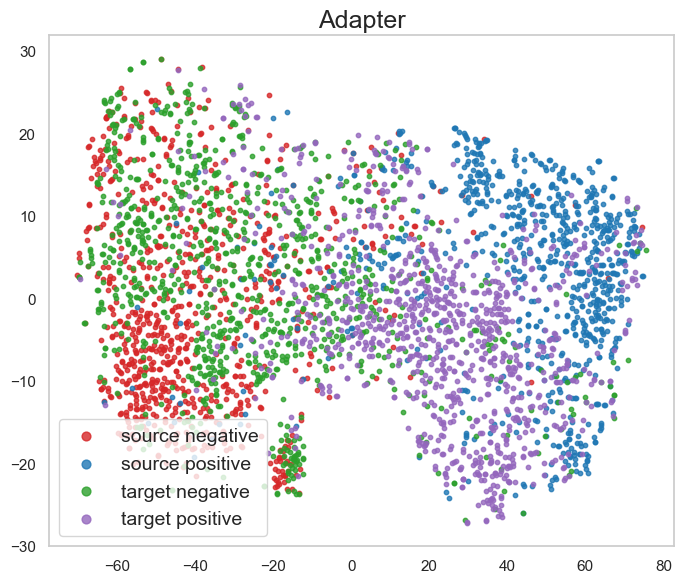

Done. Plot saved to: indobert_adapter_only\tsne_dapt_adapter.png


In [49]:
# ── Run t-SNE visualization for DAPT + Adapter (Adapter_V2) ─────────────
from pathlib import Path

device_vis = torch.device("cuda" if torch.cuda.is_available() else "cpu")
collator_vis = DataCollatorWithPadding(tokenizer=tokenizer, return_tensors="pt")

# Make sure model is in eval mode and on correct device
model.eval()
model.to(device_vis)

# ── Build dataloaders for source (labeled) and target (labeled) ──────────
g_src_vis = torch.Generator(); g_src_vis.manual_seed(SEED)
g_tgt_vis = torch.Generator(); g_tgt_vis.manual_seed(SEED + 1)

source_vis_loader = DataLoader(
    source_test_dataset,            # CoastSent test — labeled source
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator_vis,
    generator=g_src_vis,
)
target_vis_loader = DataLoader(
    target_test_dataset,            # Lazada test — labeled target
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collator_vis,
    generator=g_tgt_vis,
)

MAX_VIS_SAMPLES = 2000   # cap per domain for speed

print(f"Extracting embeddings from source ({len(source_test_dataset):,} samples, "
      f"capped at {MAX_VIS_SAMPLES})...")
Xs_src, Ys_src = extract_embeddings_adapter_model(
    model, source_vis_loader, device_vis, max_samples=MAX_VIS_SAMPLES
)

print(f"Extracting embeddings from target ({len(target_test_dataset):,} samples, "
      f"capped at {MAX_VIS_SAMPLES})...")
Xs_tgt, Ys_tgt = extract_embeddings_adapter_model(
    model, target_vis_loader, device_vis, max_samples=MAX_VIS_SAMPLES
)

print(f"Source embeddings: {Xs_src.shape} | Target embeddings: {Xs_tgt.shape}")

# ── Combine and project ───────────────────────────────────────────────────
X_all     = np.concatenate([Xs_src, Xs_tgt], axis=0)
Y_all     = np.concatenate([Ys_src, Ys_tgt], axis=0)
domains   = ["source"] * Xs_src.shape[0] + ["target"] * Xs_tgt.shape[0]

print("Running t-SNE projection (this may take ~1-2 minutes)...")
proj = project_embeddings(X_all, method="tsne", random_state=42)

# ── Plot ──────────────────────────────────────────────────────────────────
out_dir  = Path(OUTPUT_DIR)
out_dir.mkdir(parents=True, exist_ok=True)
outpath  = out_dir / "tsne_dapt_adapter.png"

plot_single_panel(
    proj     = proj,
    labels   = Y_all,
    domains  = domains,
    title    = "Adapter",
    outpath  = str(outpath),
    figsize  = (7, 6),
)

print(f"Done. Plot saved to: {outpath}")


In [50]:
# !zip -r /content/adapter_only.zip /content/indobert_adapter_only